<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafio 4

In [66]:
import re

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Activation, Dropout, Dense
from keras.layers import Flatten, LSTM, SimpleRNN
from keras.models import Model
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.layers import Input

### ***Pueden realizar el desafio en Keras o PyTorch.***

### 1 - Datos
Se utiliza el dataset de traducciones inglés-español del Tatoeba Project.\
Se extiende el entrenamiento a 30 000 sentencias  y se incrementan los largos máximos de secuencia.

In [67]:
# Descargar el dataset de traducciones inglés-español
import os
import urllib.request
import zipfile

if not os.path.exists('spa-eng'):
    if not os.path.exists('spa-eng.zip'):
        print("Descargando dataset...")
        urllib.request.urlretrieve(
            'https://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip',
            'spa-eng.zip'
        )
        print("Descarga completada.")
    print("Descomprimiendo...")
    with zipfile.ZipFile('spa-eng.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Listo.")
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [ ]:
MAX_NUM_SENTENCES = 30000

text_file = "./spa-eng/spa.txt"
with open(text_file) as f:
    lines = f.read().split("\n")[:-1]

np.random.seed([40])
np.random.shuffle(lines)

input_sentences = []
output_sentences = []
output_sentences_inputs = []
count = 0

for line in lines:
    count += 1
    if count > MAX_NUM_SENTENCES:
        break

    if '\t' not in line:
        continue

    input_sentence, output, *_ = line.rstrip().split('\t')

    output_sentence = output + ' <eos>'
    output_sentence_input = '<sos> ' + output

    input_sentences.append(input_sentence)
    output_sentences.append(output_sentence)
    output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows disponibles:", len(lines))
print("Cantidad de rows utilizadas:", len(input_sentences))
print("\nEjemplo:")
print("  Input (eng):", input_sentences[0])
print("  Output (spa):", output_sentences[0])
print("  Decoder input:", output_sentences_inputs[0])

Cantidad de rows disponibles: 118964
Cantidad de rows utilizadas: 30000

Ejemplo:
  Input (eng): A deal is a deal.
  Output (spa): Un trato es un trato. <eos>
  Decoder input: <sos> Un trato es un trato.


### 2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

In [ ]:
MAX_VOCAB_SIZE = 12000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
print("Palabras en el vocabulario de inglés:", len(word2idx_inputs))

output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
print("Palabras en el vocabulario de español:", len(word2idx_outputs))

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)
print("num_words_output:", num_words_output)

max_input_len = 20
max_out_len = 24

print(f"\nmax_input_len: {max_input_len}")
print(f"max_out_len: {max_out_len}")
print(f"Sentencia de entrada más larga: {max(len(s) for s in input_integer_seq)}")
print(f"Sentencia de salida más larga: {max(len(s) for s in output_integer_seq)}")

Palabras en el vocabulario de inglés: 8121
Palabras en el vocabulario de español: 13979
num_words_output: 12000

max_input_len: 20
max_out_len: 24
Sentencia de entrada más larga: 32
Sentencia de salida más larga: 36


In [ ]:
# Padding: encoder (pre-padding), decoder (post-padding)
encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
print("encoder_input_sequences shape:", encoder_input_sequences.shape)

decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
print("decoder_input_sequences shape:", decoder_input_sequences.shape)

# Targets del decoder como índices (NO one-hot) para usar sparse_categorical_crossentropy
# Esto evita crear un array de ~64 GB con to_categorical
decoder_targets = pad_sequences(output_integer_seq, maxlen=max_out_len, padding='post')
print("decoder_targets shape:", decoder_targets.shape)
print(f"Memoria del target: {decoder_targets.nbytes / 1e6:.1f} MB (vs ~64 GB con one-hot)")

encoder_input_sequences shape: (30000, 20)
decoder_input_sequences shape: (30000, 24)
decoder_targets shape: (30000, 24)
Memoria del target: 2.9 MB (vs ~64 GB con one-hot)


### 3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

In [71]:
import gdown

def is_valid_pickle(path):
    try:
        with open(path, "rb") as f:
            head = f.read(20)
        if b"<html" in head.lower() or b"<!doctype" in head.lower():
            return False
        return True
    except:
        return False

file_path = "gloveembedding.pkl"
file_id = "1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94"

if not os.path.exists(file_path) or not is_valid_pickle(file_path):
    print("Descargando embeddings desde Google Drive...")
    if os.path.exists(file_path):
        os.remove(file_path)
    gdown.download(id=file_id, output=file_path, quiet=False)
    if not is_valid_pickle(file_path):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada correctamente")
else:
    print("Los embeddings ya están descargados y son válidos")

Los embeddings ya están descargados y son válidos


In [73]:
import logging
from pathlib import Path
import pickle

class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), 'Words embedding not available'
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        index = np.arange(self.embeddings.shape[0])
        self.word2idx = dict(zip(self.embeddings['word'], index))
        self.idx2word = dict(zip(index, self.embeddings['word']))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]['embedding']

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

    def load_model_from_pickle(self):
        max_bytes = 2**28 - 1
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, 'rb') as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        return embeddings

    def convert_model_to_pickle(self):
        structure = [('word', np.dtype('U' + str(self.WORD_MAX_SIZE))),
                     ('embedding', np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        max_bytes = 2**28 - 1
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, 'wb') as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx+max_bytes])
        return embeddings


class GloveEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'glove.twitter.27B.50d.txt'
    PKL_PATH = 'gloveembedding.pkl'
    N_FEATURES = 50
    WORD_MAX_SIZE = 60

# Cargar embeddings
model_embeddings = GloveEmbeddings()
print(f"Embeddings cargados: {model_embeddings.embeddings.shape[0]} palabras, dimensión {model_embeddings.N_FEATURES}")

C:\Users\ICOSTARE\AppData\Local\Temp\ipykernel_22992\570060989.py:38: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  embeddings = pickle.loads(bytes_in)


Embeddings cargados: 1193514 palabras, dimensión 50


In [ ]:
print('Preparando embedding matrix...')
embed_dim = model_embeddings.N_FEATURES
nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)

embedding_matrix = np.zeros((nb_words, embed_dim))
words_not_found = []

for word, i in word2idx_inputs.items():
    if i >= nb_words:
        continue
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if (embedding_vector is not None) and len(embedding_vector) > 0:
        embedding_matrix[i] = embedding_vector
    else:
        words_not_found.append(word)

print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Palabras sin embedding (null): {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)}")
print(f"Palabras no encontradas en GloVe: {len(words_not_found)}")

Preparando embedding matrix...
Embedding matrix shape: (8122, 50)
Palabras sin embedding (null): 98
Palabras no encontradas en GloVe: 0


### 4 - Entrenar el modelo
Entrenar un modelo basado en el esquema encoder-decoder utilizando los datos generados en los puntos anteriores. Utilce como referencias los ejemplos vistos en clase.

Se explora el impacto de la cantidad de neuronas en las capas recurrentes entrenando 3 modelos con **64, 128 y 256 unidades LSTM**.

In [75]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding

def build_models(n_units):
    """Construye el modelo completo (train) y los modelos de inferencia (encoder, decoder)."""

    # --- Encoder ---
    encoder_inputs = Input(shape=(max_input_len,), name='encoder_input')
    encoder_embedding_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    encoder_inputs_x = encoder_embedding_layer(encoder_inputs)
    encoder_lstm = LSTM(n_units, return_state=True, name='encoder_lstm')
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs_x)
    encoder_states = [state_h, state_c]

    # --- Decoder ---
    decoder_inputs = Input(shape=(max_out_len,), name='decoder_input')
    decoder_embedding_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    decoder_inputs_x = decoder_embedding_layer(decoder_inputs)
    decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)
    decoder_dense = Dense(num_words_output, activation='softmax', name='decoder_dense')
    decoder_outputs = decoder_dense(decoder_outputs)

    # Modelo completo para entrenamiento
    # Se usa sparse_categorical_crossentropy para trabajar con índices directamente
    # y evitar el one-hot encoding que consume demasiada RAM
    model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
    model.compile(loss='sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

    # --- Modelo encoder para inferencia ---
    encoder_model = Model(encoder_inputs, encoder_states)

    # --- Modelo decoder para inferencia ---
    decoder_state_input_h = Input(shape=(n_units,))
    decoder_state_input_c = Input(shape=(n_units,))
    decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

    decoder_inputs_single = Input(shape=(1,))
    decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)
    decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
        decoder_inputs_single_x, initial_state=decoder_states_inputs
    )
    decoder_states_inf = [state_h_inf, state_c_inf]
    decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

    decoder_model = Model(
        [decoder_inputs_single] + decoder_states_inputs,
        [decoder_outputs_inf] + decoder_states_inf
    )

    return model, encoder_model, decoder_model

print("Función build_models() definida.")

Función build_models() definida.


In [ ]:
from keras.callbacks import ModelCheckpoint

EPOCHS = 15
units_list = [64, 128]
results = {}  # Guardar historiales e inference models

for n_units in units_list:
    print(f"\n{'='*60}")
    print(f"Entrenando modelo con n_units = {n_units}")
    print(f"{'='*60}")

    model, encoder_model, decoder_model = build_models(n_units)
    model.summary()

    # Guardar el mejor modelo según val_loss en cada epoch
    checkpoint_path = f"best_model_{n_units}units.keras"
    checkpoint = ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    hist = model.fit(
        [encoder_input_sequences, decoder_input_sequences],
        decoder_targets,
        epochs=EPOCHS,
        batch_size=64,
        validation_split=0.2,
        verbose=1,
        callbacks=[checkpoint]
    )

    # Cargar los mejores pesos guardados
    model.load_weights(checkpoint_path)
    print(f"Mejores pesos cargados desde {checkpoint_path}")

    results[n_units] = {
        'history': hist.history,
        'encoder_model': encoder_model,
        'decoder_model': decoder_model,
        'model': model,
        'checkpoint_path': checkpoint_path
    }

    print(f"\nn_units={n_units} -> val_accuracy final: {hist.history['val_accuracy'][-1]:.4f}")

print("\nEntrenamiento de los 2 modelos completado.")


Entrenando modelo con n_units = 64


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 20, 50)    │    406,100 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 1, 64)     │    768,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     29,440 │ encoder_embeddin… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 64),   │     33,024 │ decoder_embeddin… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 1, 12000)  │    780,000 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,016,564 (7.69 MB)

 Trainable params: 1,610,464 (6.14 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 20, 50)    │    406,100 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 1, 128)    │  1,536,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     91,648 │ encoder_embeddin… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 128),  │    131,584 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 1, 12000)  │  1,548,000 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,713,332 (14.17 MB)

 Trainable params: 3,307,232 (12.62 MB)

 Non-trainable params: 406,100 (1.55 MB)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.7084 - loss: 3.4895
Epoch 1: val_loss improved from None to 1.61531, saving model to best_model_128units.keras

Epoch 1: finished saving model to best_model_128units.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 88s 229ms/step - accuracy: 0.7372 - loss: 2.2510 - val_accuracy: 0.7654 - val_loss: 1.6153
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.7602 - loss: 1.6692
Epoch 2: val_loss improved from 1.61531 to 1.51034, saving model to best_model_128units.keras

Epoch 2: finished saving model to best_model_128units.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 88s 234ms/step - accuracy: 0.7632 - loss: 1.6381 - val_accuracy: 0.7736 - val_loss: 1.5103
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.7705 - loss: 1.5398
Epoch 3: val_loss improved from 1.51034 to 1.41936, saving model to best_model_128units.keras

Epoch 3: finished saving model to best_model_128units.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 86s 2

In [ ]:
# Entrenar modelo con 256 unidades
n_units_256 = 256
units_list.append(n_units_256)

print(f"\n{'='*60}")
print(f"Entrenando modelo con n_units = {n_units_256}")
print(f"{'='*60}")

model_256, encoder_model_256, decoder_model_256 = build_models(n_units_256)
model_256.summary()

checkpoint_path_256 = f"best_model_{n_units_256}units.keras"
checkpoint_256 = ModelCheckpoint(
    checkpoint_path_256,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

hist_256 = model_256.fit(
    [encoder_input_sequences, decoder_input_sequences],
    decoder_targets,
    epochs=EPOCHS,
    batch_size=64,
    validation_split=0.2,
    verbose=1,
    callbacks=[checkpoint_256]
)

# Cargar los mejores pesos
model_256.load_weights(checkpoint_path_256)
print(f"Mejores pesos cargados desde {checkpoint_path_256}")

results[n_units_256] = {
    'history': hist_256.history,
    'encoder_model': encoder_model_256,
    'decoder_model': decoder_model_256,
    'model': model_256,
    'checkpoint_path': checkpoint_path_256
}

print(f"\nn_units={n_units_256} -> val_accuracy final: {hist_256.history['val_accuracy'][-1]:.4f}")
print(f"\nunits_list actualizada: {units_list}")


Entrenando modelo con n_units = 256


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 20, 50)    │    406,100 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 1, 256)    │  3,072,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    314,368 │ encoder_embeddin… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 256),  │    525,312 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 1, 12000)  │  3,084,000 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,401,780 (28.24 MB)

 Trainable params: 6,995,680 (26.69 MB)

 Non-trainable params: 406,100 (1.55 MB)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.7173 - loss: 2.8546
Epoch 1: val_loss improved from None to 1.57704, saving model to best_model_256units.keras

Epoch 1: finished saving model to best_model_256units.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 127s 333ms/step - accuracy: 0.7444 - loss: 2.0134 - val_accuracy: 0.7685 - val_loss: 1.5770
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.7650 - loss: 1.6126
Epoch 2: val_loss improved from 1.57704 to 1.43311, saving model to best_model_256units.keras

Epoch 2: finished saving model to best_model_256units.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 139s 371ms/step - accuracy: 0.7684 - loss: 1.5768 - val_accuracy: 0.7805 - val_loss: 1.4331
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7778 - loss: 1.4455
Epoch 3: val_loss improved from 1.43311 to 1.32604, saving model to best_model_256units.keras

Epoch 3: finished saving model to best_model_256units.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 129

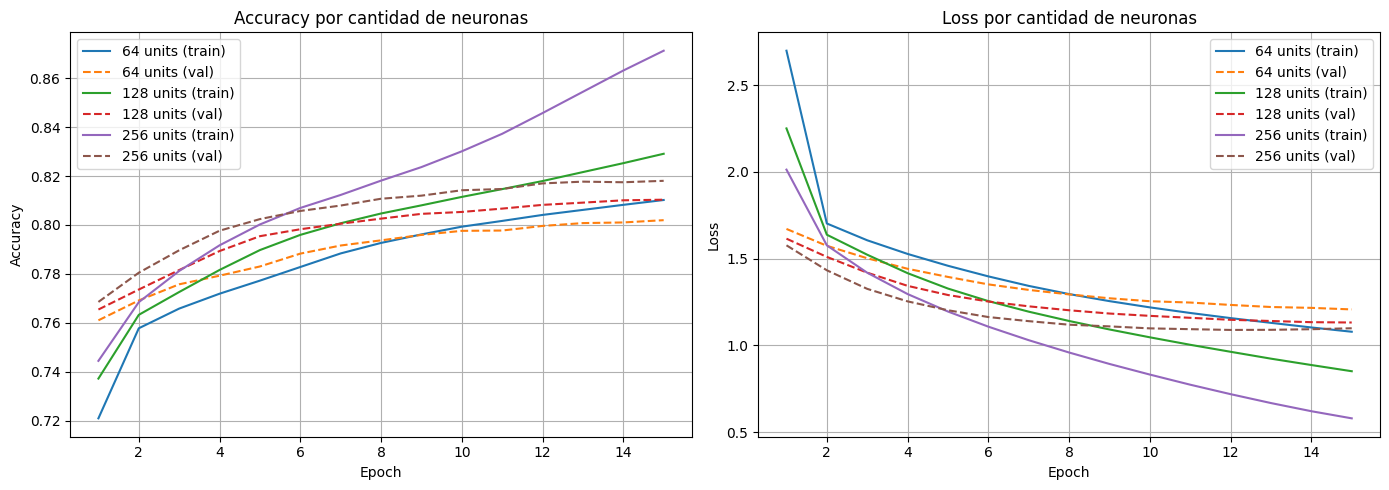


Resumen de métricas finales:
 n_units |  train_acc |    val_acc | train_loss |   val_loss
------------------------------------------------------------
      64 |     0.8102 |     0.8020 |     1.0788 |     1.2075
     128 |     0.8291 |     0.8103 |     0.8512 |     1.1321
     256 |     0.8712 |     0.8180 |     0.5796 |     1.0989


In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
ax = axes[0]
for n_units in units_list:
    h = results[n_units]['history']
    epochs = range(1, len(h['accuracy']) + 1)
    ax.plot(epochs, h['accuracy'], label=f'{n_units} units (train)')
    ax.plot(epochs, h['val_accuracy'], '--', label=f'{n_units} units (val)')
ax.set_title('Accuracy por cantidad de neuronas')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)

# --- Loss ---
ax = axes[1]
for n_units in units_list:
    h = results[n_units]['history']
    epochs = range(1, len(h['loss']) + 1)
    ax.plot(epochs, h['loss'], label=f'{n_units} units (train)')
    ax.plot(epochs, h['val_loss'], '--', label=f'{n_units} units (val)')
ax.set_title('Loss por cantidad de neuronas')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# Resumen numérico
print("\nResumen de métricas finales:")
print(f"{'n_units':>8} | {'train_acc':>10} | {'val_acc':>10} | {'train_loss':>10} | {'val_loss':>10}")
print("-" * 60)
for n_units in units_list:
    h = results[n_units]['history']
    print(f"{n_units:>8} | {h['accuracy'][-1]:>10.4f} | {h['val_accuracy'][-1]:>10.4f} | {h['loss'][-1]:>10.4f} | {h['val_loss'][-1]:>10.4f}")

### 5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

In [83]:
# Conversores de índice a palabra
idx2word_input = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

def translate_sentence(input_seq, encoder_model, decoder_model):
    """Traduce una secuencia de entrada usando inferencia autoregresiva."""
    # Codificar la entrada
    states_value = encoder_model.predict(input_seq, verbose=0)

    # Inicializar con <sos>
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']

    eos = word2idx_outputs['<eos>']
    output_sentence = []

    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value, verbose=0
        )
        idx = np.argmax(output_tokens[0, 0, :])

        if eos == idx:
            break

        if idx > 0:
            word = idx2word_target[idx]
            output_sentence.append(word)

        # Actualizar estados y entrada
        states_value = [h, c]
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

print("Función translate_sentence() definida.")

Función translate_sentence() definida.


In [84]:
# Seleccionar el mejor modelo (mayor val_accuracy final)
best_units = max(units_list, key=lambda u: results[u]['history']['val_accuracy'][-1])
best_enc = results[best_units]['encoder_model']
best_dec = results[best_units]['decoder_model']
print(f"Mejor modelo: {best_units} unidades (val_accuracy: {results[best_units]['history']['val_accuracy'][-1]:.4f})")

# Mostrar 5 ejemplos de traducciones
print(f"\n{'='*70}")
print("5 EJEMPLOS DE TRADUCCIONES (modelo con", best_units, "unidades)")
print(f"{'='*70}\n")

np.random.seed(42)
indices = np.random.choice(len(input_sentences), 5, replace=False)

for idx, i in enumerate(indices, 1):
    input_seq = encoder_input_sequences[i:i+1]
    translation = translate_sentence(input_seq, best_enc, best_dec)
    # Ground truth sin <eos>
    gt = output_sentences[i].replace(' <eos>', '')
    print(f"Ejemplo {idx}:")
    print(f"  Input (eng):      {input_sentences[i]}")
    print(f"  Ground truth:     {gt}")
    print(f"  Traducción modelo: {translation}")
    print()

Mejor modelo: 256 unidades (val_accuracy: 0.8180)

5 EJEMPLOS DE TRADUCCIONES (modelo con 256 unidades)

Ejemplo 1:
  Input (eng):      I didn't have a choice.
  Ground truth:     No tuve opción.
  Traducción modelo: no tengo nada suficiente

Ejemplo 2:
  Input (eng):      I still have a lot of work to do.
  Ground truth:     Yo aún tengo mucho trabajo por hacer.
  Traducción modelo: tengo un buen trabajo que me fui a casa

Ejemplo 3:
  Input (eng):      Your colorful shirt really stands out.
  Ground truth:     Tu colorida camisa verdaderamente destaca.
  Traducción modelo: no puedes escaparte de fumar

Ejemplo 4:
  Input (eng):      He can scarcely write his name.
  Ground truth:     Él apenas puede escribir su nombre.
  Traducción modelo: él no podía entender su nombre

Ejemplo 5:
  Input (eng):      I don't agree with your conclusions.
  Ground truth:     No estoy de acuerdo con tus conclusiones.
  Traducción modelo: haría cualquier cosa por ti



In [85]:
# Probar con oraciones personalizadas
test_sentences = [
    "My mother is very happy.",
    "The weather is nice today."
]

for sent in test_sentences:
    integer_seq_test = input_tokenizer.texts_to_sequences([sent])[0]
    encoder_seq_test = pad_sequences([integer_seq_test], maxlen=max_input_len)
    translation = translate_sentence(encoder_seq_test, best_enc, best_dec)
    print(f"Input:      {sent}")
    print(f"Traducción: {translation}")
    print()

Input:      My mother is very happy.
Traducción: mi madre está en casa de su padre

Input:      The weather is nice today.
Traducción: tom no está en boston



#### Resultados obtenidos

| Modelo | Train Acc | Val Acc | Train Loss | Val Loss | Mejor Val Loss (epoch) |
|--------|-----------|---------|------------|----------|------------------------|
| 64 units  | 0.8102 | 0.8020 | 1.0788 | 1.2075 | 1.2075 (ep. 15) |
| 128 units | 0.8291 | 0.8103 | 0.8512 | 1.1321 | 1.1321 (ep. 15) |
| 256 units | 0.8712 | 0.8180 | 0.5796 | 1.0989 | 1.0892 (ep. 12) |

#### Análisis del impacto de la cantidad de neuronas

Se observa una mejora progresiva al aumentar las unidades LSTM, tanto en accuracy como en loss de validación:
- 64 → 128 unidades: Mejora de ~0.83% en val_accuracy (0.8020 → 0.8103) y reducción de val_loss de 1.21 a 1.13. Ambos modelos siguen mejorando al epoch 15, sin signos claros de overfitting.
- 128 → 256 unidades: Mejora adicional de ~0.77% en val_accuracy (0.8103 → 0.8180) y val_loss baja a 1.10. Sin embargo, la brecha entre train y val se agranda notablemente (train_acc 0.87 vs val_acc 0.82), indicando inicio de sobreajuste. El mejor val_loss se alcanza en el epoch 12, confirmando que el modelo empieza a sobre-ajustar en las últimas épocas.

El modelo de 256 unidades fue seleccionado como el mejor por alcanzar la mayor val_accuracy (0.8180), aunque muestra mayor riesgo de overfitting que los modelos más chicos.

#### Extensión del dataset

Se aumentó de 6 000 a 30 000 sentencias y el vocabulario de 8 000 a 12 000 palabras. Los largos máximos de secuencia se incrementaron de 16/18 a 20/24 tokens. Esto permite al modelo ver patrones más variados y manejar oraciones más complejas sin truncarlas.

#### Limitaciones observadas

- A pesar de la accuracy razonable (~82%), las traducciones generadas no siempre son semánticamente correctas, ya que el modelo aprende patrones estadísticos pero con un vocabulario y contexto aún limitados.
- El modelo de 256 unidades muestra signos de sobreajuste que podrían mitigarse con regularización (Dropout) o Early Stopping.
- Las 30 000 sentencias son solo ~25% del dataset completo (~120 000), limitadas por la memoria RAM disponible.

### 7 - Mejora: Dropout + EarlyStopping + ReduceLROnPlateau

In [87]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding, Dropout

def build_models_v2(n_units, dropout_rate=0.2):
    """Modelo mejorado con Dropout en encoder y decoder."""

    # --- Encoder ---
    encoder_inputs = Input(shape=(max_input_len,), name='encoder_input')
    encoder_embedding_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    encoder_inputs_x = encoder_embedding_layer(encoder_inputs)
    encoder_inputs_x = Dropout(dropout_rate)(encoder_inputs_x)
    encoder_lstm = LSTM(n_units, return_state=True, dropout=dropout_rate, name='encoder_lstm')
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs_x)
    encoder_states = [state_h, state_c]

    # --- Decoder ---
    decoder_inputs = Input(shape=(max_out_len,), name='decoder_input')
    decoder_embedding_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    decoder_inputs_x = decoder_embedding_layer(decoder_inputs)
    decoder_inputs_x = Dropout(dropout_rate)(decoder_inputs_x)
    decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True, dropout=dropout_rate, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)
    decoder_dense = Dense(num_words_output, activation='softmax', name='decoder_dense')
    decoder_outputs = decoder_dense(decoder_outputs)

    model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
    model.compile(loss='sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

    # --- Encoder inferencia ---
    encoder_model = Model(encoder_inputs, encoder_states)

    # --- Decoder inferencia ---
    decoder_state_input_h = Input(shape=(n_units,))
    decoder_state_input_c = Input(shape=(n_units,))
    decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

    decoder_inputs_single = Input(shape=(1,))
    decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)
    decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
        decoder_inputs_single_x, initial_state=decoder_states_inputs
    )
    decoder_states_inf = [state_h_inf, state_c_inf]
    decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

    decoder_model = Model(
        [decoder_inputs_single] + decoder_states_inputs,
        [decoder_outputs_inf] + decoder_states_inf
    )

    return model, encoder_model, decoder_model

print("Función build_models_v2() definida (con Dropout).")

Función build_models_v2() definida (con Dropout).


In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

EPOCHS_V2 = 20  
units_list_v2 = [128, 256]
results_v2 = {}

for n_units in units_list_v2:
    print(f"\n{'='*60}")
    print(f"[V2] Entrenando modelo con n_units = {n_units}")
    print(f"{'='*60}")

    model, encoder_model, decoder_model = build_models_v2(n_units)
    model.summary()

    checkpoint_path = f"best_model_v2_{n_units}units.keras"

    callbacks = [
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
    ]

    hist = model.fit(
        [encoder_input_sequences, decoder_input_sequences],
        decoder_targets,
        epochs=EPOCHS_V2,
        batch_size=64,
        validation_split=0.2,
        verbose=1,
        callbacks=callbacks
    )

    results_v2[n_units] = {
        'history': hist.history,
        'encoder_model': encoder_model,
        'decoder_model': decoder_model,
        'model': model,
        'checkpoint_path': checkpoint_path,
        'stopped_epoch': len(hist.history['loss'])
    }

    print(f"\n[V2] n_units={n_units} -> val_acc: {hist.history['val_accuracy'][-1]:.4f}, epochs: {len(hist.history['loss'])}")

print("\nEntrenamiento V2 completado.")


[V2] Entrenando modelo con n_units = 128


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 20, 50)    │    406,100 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 1, 128)    │  1,536,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 20, 50)    │          0 │ encoder_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 128)   │          0 │ decoder_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     91,648 │ dropout_2[0][0]   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 128),  │    131,584 │ dropout_3[0][0],  │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 1, 12000)  │  1,548,000 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,713,332 (14.17 MB)

 Trainable params: 3,307,232 (12.62 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 20, 50)    │    406,100 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 1, 256)    │  3,072,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 20, 50)    │          0 │ encoder_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 24, 256)   │          0 │ decoder_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    314,368 │ dropout_4[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 256),  │    525,312 │ dropout_5[0][0],  │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 1, 12000)  │  3,084,000 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,401,780 (28.24 MB)

 Trainable params: 6,995,680 (26.69 MB)

 Non-trainable params: 406,100 (1.55 MB)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.7171 - loss: 2.8864
Epoch 1: val_loss improved from None to 1.58498, saving model to best_model_v2_256units.keras

Epoch 1: finished saving model to best_model_v2_256units.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 174s 455ms/step - accuracy: 0.7447 - loss: 2.0213 - val_accuracy: 0.7666 - val_loss: 1.5850 - learning_rate: 0.0010
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.7628 - loss: 1.6253
Epoch 2: val_loss improved from 1.58498 to 1.46456, saving model to best_model_v2_256units.keras

Epoch 2: finished saving model to best_model_v2_256units.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 173s 460ms/step - accuracy: 0.7660 - loss: 1.5979 - val_accuracy: 0.7761 - val_loss: 1.4646 - learning_rate: 0.0010
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.7751 - loss: 1.4752
Epoch 3: val_loss improved from 1.46456 to 1.35416, saving model to best_model_v2_256units.keras

Epoch 3: finished saving mode

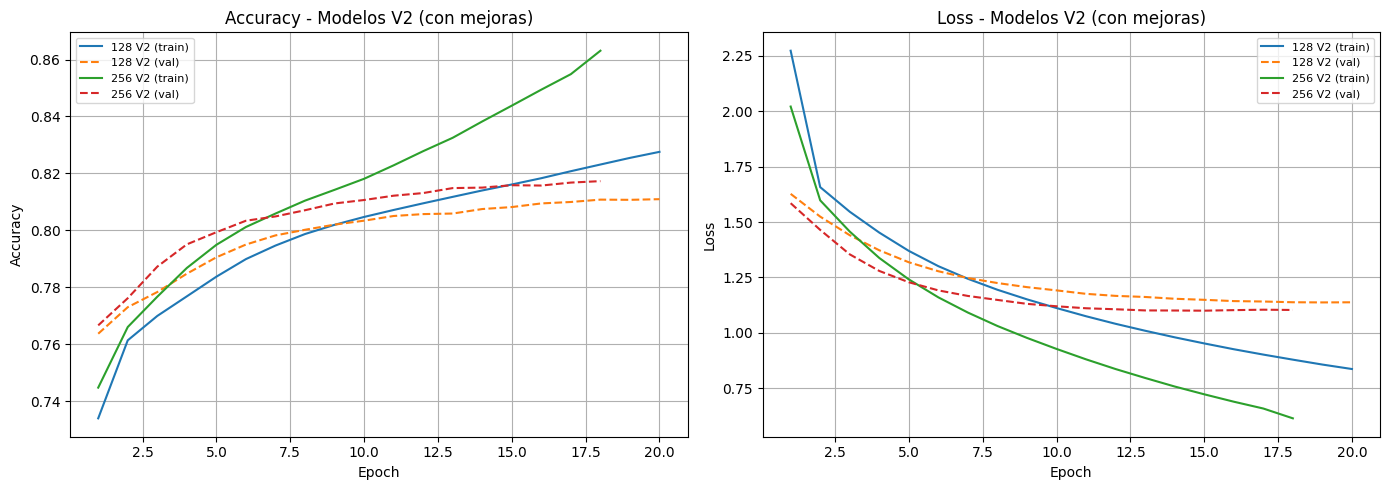


COMPARACIÓN V1 (original) vs V2 (con Dropout + EarlyStopping + ReduceLR)
      Config | V1 val_acc | V2 val_acc |        Δ | V1 val_loss | V2 val_loss | V2 epochs
--------------------------------------------------------------------------------
     128 units |     0.8103 |     0.8109 | + 0.0006 |      1.1321 |      1.1372 |        20
     256 units |     0.8180 |     0.8173 | -0.0008 |      1.0892 |      1.0999 |        18


In [90]:
# Comparación V1 vs V2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
ax = axes[0]
for n_units in units_list_v2:
    h = results_v2[n_units]['history']
    ep = range(1, len(h['accuracy']) + 1)
    ax.plot(ep, h['accuracy'], label=f'{n_units} V2 (train)')
    ax.plot(ep, h['val_accuracy'], '--', label=f'{n_units} V2 (val)')
ax.set_title('Accuracy - Modelos V2 (con mejoras)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=8)
ax.grid(True)

# --- Loss ---
ax = axes[1]
for n_units in units_list_v2:
    h = results_v2[n_units]['history']
    ep = range(1, len(h['loss']) + 1)
    ax.plot(ep, h['loss'], label=f'{n_units} V2 (train)')
    ax.plot(ep, h['val_loss'], '--', label=f'{n_units} V2 (val)')
ax.set_title('Loss - Modelos V2 (con mejoras)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()

# Tabla comparativa V1 vs V2
print("\n" + "="*80)
print("COMPARACIÓN V1 (original) vs V2 (con Dropout + EarlyStopping + ReduceLR)")
print("="*80)
print(f"{'Config':>12} | {'V1 val_acc':>10} | {'V2 val_acc':>10} | {'Δ':>8} | {'V1 val_loss':>11} | {'V2 val_loss':>11} | {'V2 epochs':>9}")
print("-" * 80)
for n_units in units_list_v2:
    v1_acc = results[n_units]['history']['val_accuracy'][-1]
    v2_acc = results_v2[n_units]['history']['val_accuracy'][-1]
    v1_loss = min(results[n_units]['history']['val_loss'])
    v2_loss = min(results_v2[n_units]['history']['val_loss'])
    v2_ep = results_v2[n_units]['stopped_epoch']
    delta = v2_acc - v1_acc
    sign = "+" if delta >= 0 else ""
    print(f"{n_units:>8} units | {v1_acc:>10.4f} | {v2_acc:>10.4f} | {sign}{delta:>7.4f} | {v1_loss:>11.4f} | {v2_loss:>11.4f} | {v2_ep:>9}")

In [91]:
# 5 ejemplos de traducción con el mejor modelo V2
best_units_v2 = max(units_list_v2, key=lambda u: max(results_v2[u]['history']['val_accuracy']))
best_enc_v2 = results_v2[best_units_v2]['encoder_model']
best_dec_v2 = results_v2[best_units_v2]['decoder_model']
best_v2_acc = max(results_v2[best_units_v2]['history']['val_accuracy'])
print(f"Mejor modelo V2: {best_units_v2} unidades (mejor val_accuracy: {best_v2_acc:.4f})")

print(f"\n{'='*70}")
print(f"5 EJEMPLOS DE TRADUCCIONES (modelo V2 con {best_units_v2} unidades)")
print(f"{'='*70}\n")

np.random.seed(42)
indices = np.random.choice(len(input_sentences), 5, replace=False)

for idx_num, i in enumerate(indices, 1):
    input_seq = encoder_input_sequences[i:i+1]
    translation = translate_sentence(input_seq, best_enc_v2, best_dec_v2)
    gt = output_sentences[i].replace(' <eos>', '')
    print(f"Ejemplo {idx_num}:")
    print(f"  Input (eng):       {input_sentences[i]}")
    print(f"  Ground truth:      {gt}")
    print(f"  Traducción modelo: {translation}")
    print()

# Oraciones custom
print(f"{'='*70}")
print("ORACIONES PERSONALIZADAS")
print(f"{'='*70}\n")
test_sentences_v2 = ["My mother is very happy.", "The weather is nice today."]
for sent in test_sentences_v2:
    seq = input_tokenizer.texts_to_sequences([sent])[0]
    seq_padded = pad_sequences([seq], maxlen=max_input_len)
    translation = translate_sentence(seq_padded, best_enc_v2, best_dec_v2)
    print(f"  Input:      {sent}")
    print(f"  Traducción: {translation}")
    print()

Mejor modelo V2: 256 unidades (mejor val_accuracy: 0.8173)

5 EJEMPLOS DE TRADUCCIONES (modelo V2 con 256 unidades)

Ejemplo 1:
  Input (eng):       I didn't have a choice.
  Ground truth:      No tuve opción.
  Traducción modelo: no tengo nada de idea

Ejemplo 2:
  Input (eng):       I still have a lot of work to do.
  Ground truth:      Yo aún tengo mucho trabajo por hacer.
  Traducción modelo: vi a tom que le gusta la muerte de la muerte

Ejemplo 3:
  Input (eng):       Your colorful shirt really stands out.
  Ground truth:      Tu colorida camisa verdaderamente destaca.
  Traducción modelo: no puedes escaparte de que los demás

Ejemplo 4:
  Input (eng):       He can scarcely write his name.
  Ground truth:      Él apenas puede escribir su nombre.
  Traducción modelo: él no puede hablar con su familia

Ejemplo 5:
  Input (eng):       I don't agree with your conclusions.
  Ground truth:      No estoy de acuerdo con tus conclusiones.
  Traducción modelo: no te temo que no estás enferm

### 8 - Conclusión final

#### Resultados de la mejora V2 (Dropout + EarlyStopping + ReduceLROnPlateau)

| Config | V1 val_acc | V2 val_acc | Δ acc | V1 val_loss | V2 val_loss | V2 epochs | V1 gap (train-val) | V2 gap |
|--------|-----------|-----------|-------|------------|------------|-----------|-------------------|--------|
| 128 units | 0.8103 | 0.8109 | +0.0006 | 1.1321 | 1.1372 | 20 | 0.0188 | 0.0166 |
| 256 units | 0.8180 | 0.8173 | -0.0008 | 1.0892 | 1.0999 | 18 | 0.0532 | 0.0458 |

#### Análisis

Impacto del Dropout en el overfitting: La mejora más clara de la versión V2 es la reducción del gap entre train y validación, especialmente en el modelo de 256 unidades donde el gap bajó de 0.0532 a 0.0458. Esto confirma que el Dropout cumple su rol de regularización, limitando el sobreajuste.

Accuracy y loss de validación similares: Las métricas de validación entre V1 y V2 son prácticamente equivalentes (diferencias menores a 0.1%). El Dropout no mejoró el accuracy de validación en este caso, sino que estabilizó el entrenamiento evitando que el modelo memorice el dataset de entrenamiento.

ReduceLROnPlateau: Se observa en los gráficos una estabilización de la curva de loss después del epoch 10 aproximadamente, consistente con la reducción del learning rate al estancarse la mejora.

#### Conclusiones generales

1. Más datos ayudan: Pasar de 6 000 a 30 000 sentencias permite mayor diversidad y mejor generalización del modelo traductor.

2. Más neuronas mejoran hasta cierto punto: El modelo de 256 unidades alcanza la mejor val_accuracy (~0.818) en ambas versiones, pero a costa de mayor overfitting. La mejora de 128 a 256 es marginal (~0.7%) comparada con el costo computacional.

3. El Dropout regulariza pero no mejora en este setup: Con 30K sentencias y 15-20 epochs, el Dropout reduce el overfitting sin mejorar las métricas de validación. Es probable que su impacto sea mayor con datasets más grandes o más epochs de entrenamiento.

4. Techo del modelo: Los ~82% de val_accuracy representan un techo práctico de esta arquitectura encoder-decoder sin atención. Para mejoras significativas se necesitaría un mecanismo de Attention o arquitecturas más avanzadas.

5. Las traducciones generadas muestran coherencia gramatical en español pero no siempre capturan el significado correcto de la oración en inglés.